# Retail Store Sales Analysis — Business Performance Dashboard
This notebook analyses sales data from a retail company to identify 
top-performing products, regional profit trends, and seasonal patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist()) # Returns all columns as a list
print("\nMissing values:") # Shows all columns with missing values
print(df.isnull().sum())

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
# Preparing the date column by converting the 'Order Date' column from text to an actual date format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extracting the year and month for grouping later
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df['Order Date'].dtype

dtype('<M8[us]')

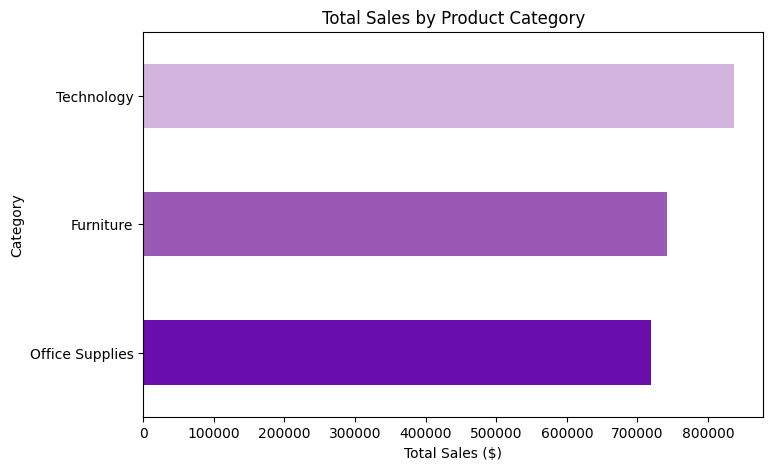

In [5]:
# Displaying the cells by category on a horizontal bar chart
plt.figure(figsize=(8, 5))
# Using ".groupby('Category')" to group all rows based on their category
# Then "['Sales'].sum()" to add up the total sales for each category
# Then ".sort_values()" to sort them in descending order, making the chart easier to read
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
category_sales.plot(kind='barh', color=['#6a0dad', '#9b59b6', '#d2b4de'])
plt.title('Total Sales by Product Category')
plt.xlabel('Total Sales ($)')
plt.ylabel('Category')
plt.show()

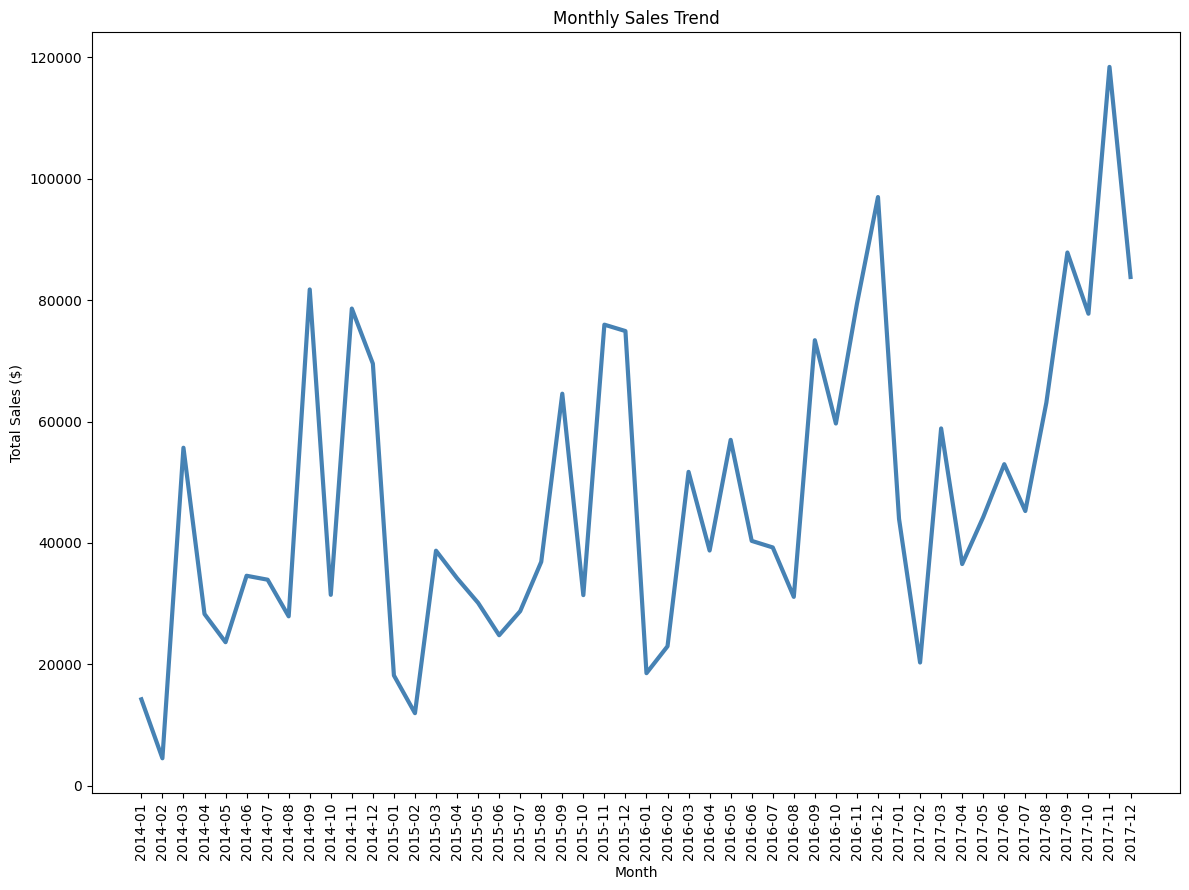

In [6]:
# Creating a line chart showing the monthly sales trend
plt.figure(figsize=(12, 9))
# Grouping by Year & Month, adding up the sales in each category
# Then used ".reset_index()" to set each group as the row labels
# That is, convert them back to regular columns
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
# Using ".astype(str)" to convert the numbers to text so they can be concatenated
# Then ".str.zfill(2)" to pad single-digit months with a 0, ensuring correct sorting
monthly_sales['Period'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)
monthly_sales = monthly_sales.sort_values('Period')

plt.plot(monthly_sales['Period'], monthly_sales['Sales'], color='steelblue', linewidth=3)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
# Rotating all x-axis labels to 90° so they don't overlap
plt.xticks(rotation=90, fontsize=10) 
plt.tight_layout() # Adjusting spacing so nothing gets cut off
plt.show()

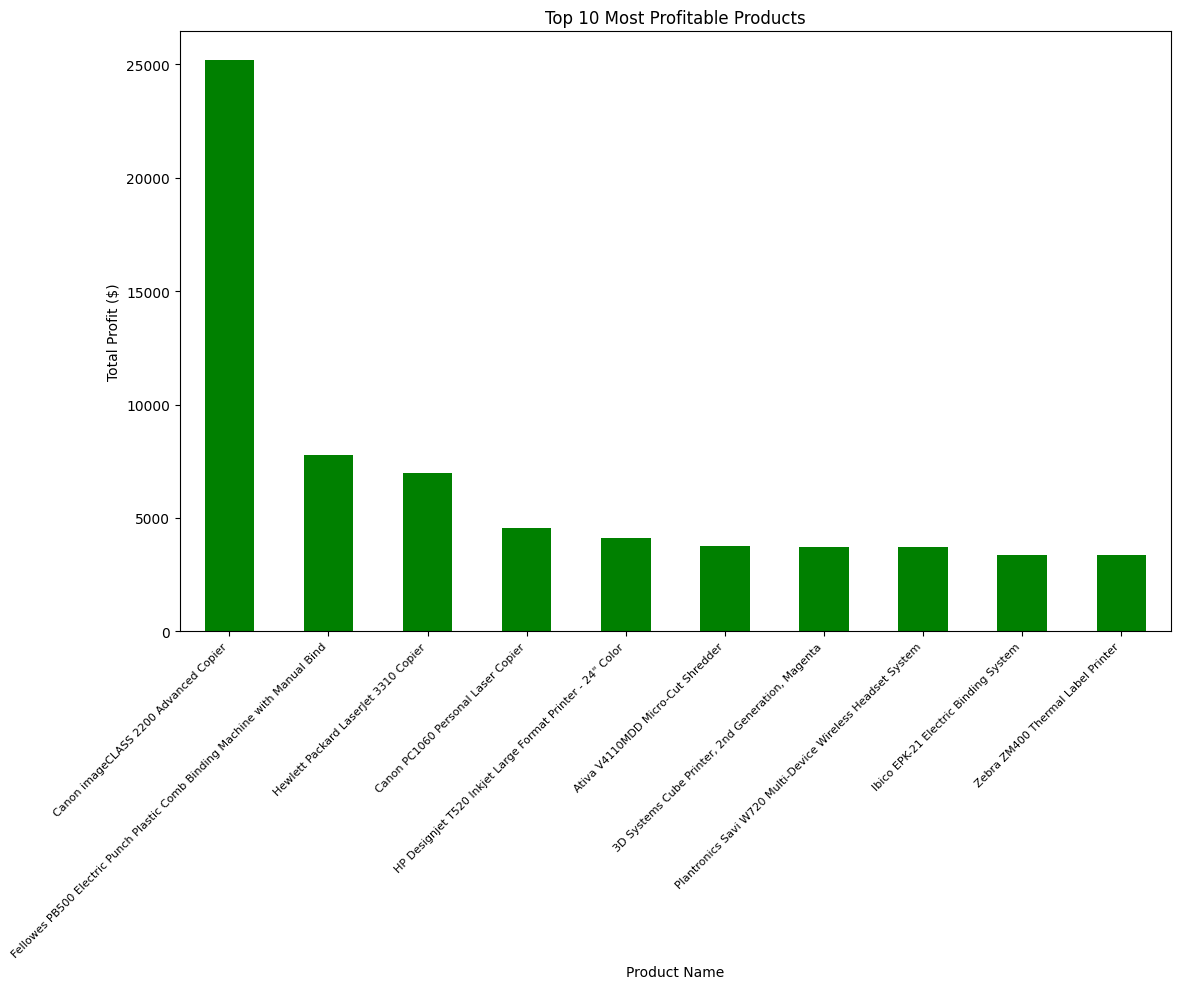

In [7]:
# Creating a bar chart to display the top 10 most profitable products
plt.figure(figsize=(12, 10))
# Grouping by product name, adding up the profit for each product
# Then displaying in descending order and selecting just the top 10
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', color='green')
plt.title('Top 10 Most Profitable Products')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

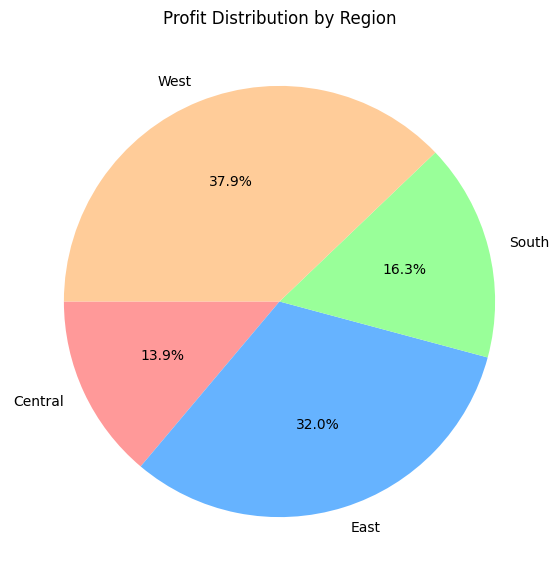

In [8]:
# Creating a pie chart to display the profit by region
plt.figure(figsize=(7, 7))
# Grouping by region and adding up the profit
region_profit = df.groupby('Region')['Profit'].sum()
# Using "autopct='%1.1f%%'" to auto calc and display the % of each slice
# Setting the chart's startangle to 140°
region_profit.plot(kind='pie', autopct='%1.1f%%', startangle=180, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Profit Distribution by Region')
plt.ylabel('')
plt.show()

## Business Insights

1. **Technology is the highest-revenue category**, outperforming Furniture 
   and Office Supplies significantly.

2. **Sales peak in November and December**, indicating strong seasonal demand 
   — likely holiday shopping. This signals an opportunity for targeted 
   promotions in Q4.

3. **A small number of products drive disproportionate profit** — the top 10 
   products represent a significant portion of total margins. Prioritising 
   these SKUs in inventory and marketing would be high-impact.

4. **The West region generates the largest profit share**, while the Central 
   region underperforms relative to its size.